# Exploratory Data Analysis: Predicting Hard-Drive Failure from SMART Telemetry
**IST 707 – Applied Machine Learning · Final Project**

---

This notebook explores the modeling datasets (`modeling_train`, `modeling_calib`, `modeling_test`) used to
predict **whether a hard drive will fail** based on its SMART (Self-Monitoring, Analysis and Reporting
Technology) telemetry. It is organised as follows:

| § | Section | Purpose |
|---|---|---|
| 1 | Setup | Libraries, plotting style, helper functions |
| 2 | **Dataset provenance** | Where the data comes from, how it was built, size & features, *why we trust it* |
| 3 | Data quality audit | Missingness, keys, temporal integrity, physical plausibility |
| 4 | **Statistical Analysis 1** | Class imbalance and the train → test prior shift |
| 5 | **Statistical Analysis 2** | Who fails? Failure rates by manufacturer, model and drive age |
| 6 | **Statistical Analysis 3** | SMART signatures of failing vs healthy drives (hypothesis tests & effect sizes) |
| 7 | **Statistical Analysis 4** | Raw vs vendor-*normalized* SMART values: what normalization does to the signal |
| 8 | **Statistical Analysis 5** | Correlation, redundancy, degradation (deltas) and information ranking |
| 9 | Conclusions | What we learned and how it shapes the modeling |

Every analysis opens with a short statement of **what it shows and why it matters**, and closes with an interpretation.

## 1. Setup

In [33]:
import warnings, os, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# ---- palette (colorblind-validated categorical order) ----
HEALTHY, FAILED = "#2a78d6", "#eb6834"          # class colours used everywhere
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SPLIT_COL = {"train": SERIES[0], "calib": SERIES[2], "test": SERIES[1]}
VENDOR_COL = {"Seagate": SERIES[0], "Toshiba": SERIES[1], "WDC": SERIES[2], "HGST": SERIES[6], "Other": "#9a9a96"}
DIVERGING = sns.blend_palette(["#184f95", "#f0efec", "#b52f2f"], as_cmap=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#8a8984",
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.7, "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelsize": 10.5, "axes.labelcolor": "#2b2b2a",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False, "font.size": 10,
    "lines.linewidth": 2,
})

DATA_DIR = "."
SPLITS = ["train", "calib", "test"]

SMART_IDS = [1, 3, 4, 5, 7, 9, 10, 12, 192, 193, 194, 197, 198, 199]
SMART_NAMES = {
    1: "Read Error Rate", 3: "Spin-Up Time", 4: "Start/Stop Count", 5: "Reallocated Sectors",
    7: "Seek Error Rate", 9: "Power-On Hours", 10: "Spin Retry Count", 12: "Power Cycle Count",
    192: "Power-Off Retract Count", 193: "Load/Unload Cycles", 194: "Temperature (°C)",
    197: "Current Pending Sectors", 198: "Offline Uncorrectable", 199: "UltraDMA CRC Errors",
}
def sname(i): return f"S{i} {SMART_NAMES[i]}"

def vendor(model: str) -> str:
    m = str(model)
    if m.startswith("ST"): return "Seagate"
    if m.startswith("TOSHIBA"): return "Toshiba"
    if m.startswith(("WDC", "WUH")): return "WDC"
    if m.startswith(("HGST", "Hitachi")): return "HGST"
    return "Other"

def wilson(k, n, z=1.96):
    # Wilson score interval for a binomial proportion
    k, n = np.asarray(k, float), np.asarray(n, float)
    p = k / n
    den = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return p, centre - half, centre + half

def oriented_auc(y, x):
    # AUC with direction removed: 0.5 = no signal, 1.0 = perfect separation
    m = ~np.isnan(x)
    if np.unique(x[m]).size < 2: return 0.5
    a = roc_auc_score(y[m], x[m])
    return max(a, 1 - a)

def pct(x, d=2): return f"{100*x:.{d}f}%"
print("Libraries loaded.")

Libraries loaded.


### 1.1 Loading the data
`modeling_train` and `modeling_calib` are small enough to load in full. `modeling_test` has **3.5 million rows**,
so we load only the columns needed for each analysis. This keeps memory manageable without dropping any rows.

In [34]:
t0 = time.time()
train = pd.read_parquet(f"{DATA_DIR}/modeling_train.parquet")
calib = pd.read_parquet(f"{DATA_DIR}/modeling_calib.parquet")

KEY_RAW  = [f"smart_{i}_raw_last" for i in SMART_IDS]
KEY_NORM = [f"smart_{i}_normalized_last" for i in SMART_IDS]
META = ["serial_number", "window", "window_first_date", "window_last_date", "days_observed",
        "days_span", "capacity_bytes", "model", "label", "drive_days_to_date"]
test = pd.read_parquet(f"{DATA_DIR}/modeling_test.parquet",
                       columns=META + KEY_RAW + KEY_NORM + ["smart_5_raw_delta", "smart_197_raw_delta", "smart_198_raw_delta"])

for name, df in [("train", train), ("calib", calib), ("test", test)]:
    df["vendor"] = df["model"].map(vendor)
    df["capacity_tb"] = (df["capacity_bytes"] / 1e12).round(0)
    df["age_years"] = df["smart_9_raw_last"] / (24 * 365.25)

DFS = {"train": train, "calib": calib, "test": test}
print(f"Loaded in {time.time()-t0:.1f}s")
for k, d in DFS.items():
    print(f"{k:>5}: {d.shape[0]:>10,} rows × {d.shape[1]:>3} cols loaded   |  {d.memory_usage(deep=True).sum()/1e6:,.0f} MB in memory")

Loaded in 4.9s
train:    169,827 rows ×  97 cols loaded   |  106 MB in memory
calib:    297,009 rows ×  97 cols loaded   |  185 MB in memory
 test:  3,521,973 rows ×  44 cols loaded   |  1,095 MB in memory


## 2. Dataset Provenance

### 2.1 Where the data came from

todo

### 2.2 Size and features

In [35]:
sizes = []
for k in SPLITS:
    d = DFS[k]
    sizes.append({
        "split": k,
        "file size (MB)": os.path.getsize(f"{DATA_DIR}/modeling_{k}.parquet") / 1e6,
        "rows (drive-windows)": len(d),
        "columns in file": 94,
        "unique drives": d["serial_number"].nunique(),
        "drive models": d["model"].nunique(),
        "failures (label=1)": int(d["label"].sum()),
        "failure rate": d["label"].mean(),
        "first date": d["window_first_date"].min().date(),
        "last date": d["window_last_date"].max().date(),
        "windows": f'{d["window"].min()}–{d["window"].max()}',
    })
sizes = pd.DataFrame(sizes).set_index("split")
display(sizes.style.format({"file size (MB)": "{:,.1f}", "rows (drive-windows)": "{:,}", "unique drives": "{:,}",
                            "failures (label=1)": "{:,}", "failure rate": "{:.3%}"}))
total = sizes["rows (drive-windows)"].sum()
print(f"Total: {total:,} drive-windows ≈ {total*30/1e6:,.0f} million drive-days of telemetry")

,file size (MB),rows (drive-windows),columns in file,unique drives,drive models,failures (label=1),failure rate,first date,last date,windows
split,,,,,,,,,,
train,9.0,"169,827",94,"131,815",63,"8,087",4.762%,2023-01-01,2024-10-21,0–21
calib,13.0,"297,009",94,"293,236",55,328,0.110%,2024-11-01,2024-12-20,22–23
test,141.4,"3,521,973",94,"344,023",59,"3,722",0.106%,2025-01-01,2025-12-15,24–35


Total: 3,988,809 drive-windows ≈ 120 million drive-days of telemetry


In [36]:
# Feature catalogue: 94 columns in 6 families
fam = []
for c in train.columns:
    if c in ("vendor", "capacity_tb", "age_years"): continue
    if c.startswith("smart_"):
        parts = c.split("_"); i = int(parts[1]); kind = parts[2]; stat = parts[3]
        fam.append((f"SMART {kind} · {stat}", c, str(train[c].dtype)))
    else:
        fam.append(("identifier / metadata" if c not in ("label",) else "target", c, str(train[c].dtype)))
fam = pd.DataFrame(fam, columns=["family", "column", "dtype"])
summary = fam.groupby("family").agg(n_columns=("column", "size"), example=("column", "first"), dtype=("dtype", "first"))
display(summary)
print("Metadata columns:", [c for c in fam.loc[fam.family.str.startswith('identifier'), 'column']])

,n_columns,example,dtype
family,,,
SMART normalized · delta,14,smart_10_normalized_delta,float32
SMART normalized · first,14,smart_10_normalized_first,float32
SMART normalized · last,14,smart_10_normalized_last,float32
SMART raw · delta,14,smart_10_raw_delta,float64
SMART raw · first,14,smart_10_raw_first,float64
SMART raw · last,14,smart_10_raw_last,float64
identifier / metadata,9,serial_number,string
target,1,label,int8


Metadata columns: ['serial_number', 'window', 'window_first_date', 'window_last_date', 'days_observed', 'capacity_bytes', 'model', 'days_span', 'drive_days_to_date']


In [37]:
train.describe()

,window,smart_10_normalized_first,smart_10_normalized_last,smart_10_raw_first,smart_10_raw_last,smart_12_normalized_first,smart_12_normalized_last,smart_12_raw_first,smart_12_raw_last,smart_192_normalized_first,smart_192_normalized_last,smart_192_raw_first,smart_192_raw_last,smart_193_normalized_first,smart_193_normalized_last,smart_193_raw_first,smart_193_raw_last,smart_194_normalized_first,smart_194_normalized_last,smart_194_raw_first,smart_194_raw_last,smart_197_normalized_first,smart_197_normalized_last,smart_197_raw_first,smart_197_raw_last,smart_198_normalized_first,smart_198_normalized_last,smart_198_raw_first,smart_198_raw_last,smart_199_normalized_first,smart_199_normalized_last,smart_199_raw_first,smart_199_raw_last,smart_1_normalized_first,smart_1_normalized_last,smart_1_raw_first,smart_1_raw_last,smart_3_normalized_first,smart_3_normalized_last,smart_3_raw_first,smart_3_raw_last,smart_4_normalized_first,smart_4_normalized_last,smart_4_raw_first,smart_4_raw_last,smart_5_normalized_first,smart_5_normalized_last,smart_5_raw_first,smart_5_raw_last,smart_7_normalized_first,smart_7_normalized_last,smart_7_raw_first,smart_7_raw_last,smart_9_normalized_first,smart_9_normalized_last,smart_9_raw_first,smart_9_raw_last,window_first_date,window_last_date,days_observed,capacity_bytes,days_span,smart_10_normalized_delta,smart_10_raw_delta,smart_12_normalized_delta,smart_12_raw_delta,smart_192_normalized_delta,smart_192_raw_delta,smart_193_normalized_delta,smart_193_raw_delta,smart_194_normalized_delta,smart_194_raw_delta,smart_197_normalized_delta,smart_197_raw_delta,smart_198_normalized_delta,smart_198_raw_delta,smart_199_normalized_delta,smart_199_raw_delta,smart_1_normalized_delta,smart_1_raw_delta,smart_3_normalized_delta,smart_3_raw_delta,smart_4_normalized_delta,smart_4_raw_delta,smart_5_normalized_delta,smart_5_raw_delta,smart_7_normalized_delta,smart_7_raw_delta,smart_9_normalized_delta,smart_9_raw_delta,label,drive_days_to_date,capacity_tb,age_years
count,"169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,602.0000","169,602.0000","169,602.0000","169,602.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","166,097.0000","166,097.0000","166,097.0000","166,097.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000",169827,169827,"169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,602.0000","169,602.0000","169,827.0000","169,827.0000","166,097.0000","166,097.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000","169,827.0000"
mean,10.9036,100.2006,100.2007,9.2616,9.2616,99.9986,99.9986,11.7991,12.0213,100.0081,100.0059,436.7200,444.7646,96.2442,96.2083,"8,417.2859","8,493.8549",78.4399,78.2998,33.0680,33.1499,100.2632,100.2468,3.1827,12.9464,100.1923,100.1766,2.3294,11.3897,186.5033,186.5033,3.2461,3.2677,93.1233,93.0793,"51,979,336.4168","51,995,372.2672",97.9647,98.0654,"2,238.0607","2,239.6879",99.9985,99.9985,13.7578,13.9822,100.2063,100.1767,91.7697,130.8083,94.5348,94.5594,"706,890,656.3930","2,430,712,390.9517",69.1093,68.2909,"28,287.5089","28,967.2885",2023-11-24 08:15:20.842975488,2023-12-23 02:32:11.608047872,29.

**SMART attribute dictionary.** For each attribute we have a *raw* value and a *normalized* value. The raw value is
usually a physical count (sectors, hours, °C, events). The normalized value is a score that is computed inside the
drive firmware, usually on a 1–253 scale. It starts at 100 or 200 and counts **down** as the drive's health gets worse.

|  ID | Attribute                    | Unit        | What the raw value measures                                                                                                                          |
| --: | ---------------------------- | ----------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
|   1 | Read Error Rate              | Read errors | **Vendor-encoded on Seagate** (several counters packed into one number), so raw values are not comparable across manufacturers. Normalized is safer. |
|   3 | Spin-Up Time                 | Time        | Time for the platters to reach full speed. Units vary by vendor.                                                                                     |
|   4 | Start/Stop Count             | Count       | Number of spindle start and stop cycles.                                                                                                             |
|   5 | Reallocated Sectors Count    | Count       | Bad sectors remapped to spare area. **One of Backblaze's headline failure predictors**, and baseline 1 is `smart_5_raw_last > 0`.                    |
|   7 | Seek Error Rate              | Seek errors | Head positioning errors. **Vendor-encoded on Seagate**, same caveat as ID 1.                                                                         |
|   9 | Power-On Hours               | Hours       | Lifetime hours powered on. The drive's real age.                                                                                                     |
|  10 | Spin Retry Count             | Count       | Times the drive had to retry spinning up.                                                                                                            |
|  12 | Power Cycle Count            | Count       | Full power-on and off cycles.                                                                                                                        |
| 192 | Power-Off Retract Count      | Count       | Emergency head retracts, typically from unsafe shutdowns.                                                                                            |
| 193 | Load/Unload Cycle Count      | Count       | Times the heads parked and unparked.                                                                                                                 |
| 194 | Temperature                  | °C          | Drive temperature in degrees Celsius.                                                                                                                |
| 197 | Current Pending Sector Count | Count       | Unstable sectors waiting to be remapped. **Headline predictor.**                                                                                     |
| 198 | Offline Uncorrectable        | Count       | Sectors that failed the drive's offline scan. **Headline predictor.**                                                                                |
| 199 | UltraDMA CRC Error Count     | Count       | Data transfer errors on the cable or interface, usually a cabling problem rather than the disk itself.                                               |



### 2.3 Why we trust this data

1. Credible Source: Blackblaze collects its data directly form the production hardware, it has being published since a decade, and everything is well documented. It has also been previosly used in multiple studies.
2. No Manual Entry. No human survey is used in collecting the data, thus there can be no human eror or any bias.
3. Scale. There are over 4 million drive windows accriss 60 drive models.
4. We auditted it ourselves (below) to check for uniquness, label logic, and plausibilty.

In [38]:
checks = []
def chk(name, ok, detail): checks.append({"check": name, "result": "PASS" if ok else "REVIEW", "evidence": detail})

for k in SPLITS:
    d = DFS[k]
    dup = d.duplicated(["serial_number", "window"]).sum()
    chk(f"[{k}] (serial, window) is a unique key", dup == 0, f"{dup} duplicate keys")

chk("Splits are temporally disjoint (train < calib < test)",
    train.window_last_date.max() < calib.window_first_date.min() <= calib.window_last_date.max() < test.window_first_date.min(),
    f"train ends {train.window_last_date.max().date()}, calib {calib.window_first_date.min().date()}→{calib.window_last_date.max().date()}, test starts {test.window_first_date.min().date()}")

ratio = (train.label == 0).sum() / (train.label == 1).sum()
chk("Train negatives were down-sampled at a fixed 20:1 ratio", abs(ratio - 20) < 1e-9, f"neg/pos = {ratio:.4f}")

for k in SPLITS:
    d = DFS[k]
    last_w = d.groupby("serial_number")["window"].transform("max")
    p = d.label == 1
    share = (d.loc[p, "window"] == last_w[p]).mean()
    multi = d.loc[p, "serial_number"].duplicated().sum()
    chk(f"[{k}] A failure is the drive's final window", share > 0.995, f"{share:.4%} of failures are the last window; {multi} drives fail twice")

t_lo, t_hi = train.smart_194_raw_last.min(), train.smart_194_raw_last.max()
chk("Temperature (S194 raw) is physically plausible", 5 <= t_lo and t_hi <= 70, f"range {t_lo:.0f}–{t_hi:.0f} °C")

full = train[(train.days_span == 29)]
poh_ratio = (full.smart_9_raw_delta / (full.days_span * 24)).median()
chk("Power-on-hour delta matches calendar time (≈24 h/day)", 0.95 < poh_ratio < 1.05, f"median ΔPOH / (24·Δdays) = {poh_ratio:.3f}")

miss = train.isna().mean().max()
chk("Missingness is low", miss < 0.05, f"worst column {train.isna().mean().idxmax()} = {miss:.2%} missing")

neg_raw = (train[[c for c in train.columns if c.endswith(('_raw_last', '_raw_first'))]] < 0).sum().sum()
chk("Raw counters are non-negative", neg_raw == 0, f"{neg_raw} negative raw values")

display(pd.DataFrame(checks).style.map(lambda v: "color:#008300;font-weight:bold" if v == "PASS" else "color:#b52f2f;font-weight:bold", subset=["result"]))

,check,result,evidence
0,"[train] (serial, window) is a unique key",PASS,0 duplicate keys
1,"[calib] (serial, window) is a unique key",PASS,0 duplicate keys
2,"[test] (serial, window) is a unique key",PASS,0 duplicate keys
3,Splits are temporally disjoint (train < calib < test),PASS,"train ends 2024-10-21, calib 2024-11-01→2024-12-20, test starts 2025-01-01"
4,Train negatives were down-sampled at a fixed 20:1 ratio,PASS,neg/pos = 20.0000
5,[train] A failure is the drive's final window,PASS,99.9629% of failures are the last window; 1 drives fail twice
6,[calib] A failure is the drive's final window,PASS,100.0000% of failures are the last window; 0 drives fail twice
7,[test] A failure is the drive's final window,PASS,99.5701% of failures are the last window; 0 drives fail twice
8,Temperature (S194 raw) is physically plausible,PASS,range 13–59 °C
9,Power-on-hour delta matches calendar time (≈24 h/day),PASS,median ΔPOH / (24·Δdays) = 1.000


**Interpretation: the audit passes on every check.**
Each roew is unique and the testing windows do not overlap. We also verified the 20:1 down sampling ratio, meaning that we can undo the down sampling mathematically. The physical features like the temperature also have a range that is theoraticaly and physically pausible.

## 3. Data Quality Audit

### 3.1 Missing values

Here we are examining the amount of missing values in each column, and which drives and models the missing values belong to. We need to examinr this because if the missing values are totally random it is possible for us to interpolate them, hovewer if the missing values are due to things like the modle of the drive then we can not simply impute it.

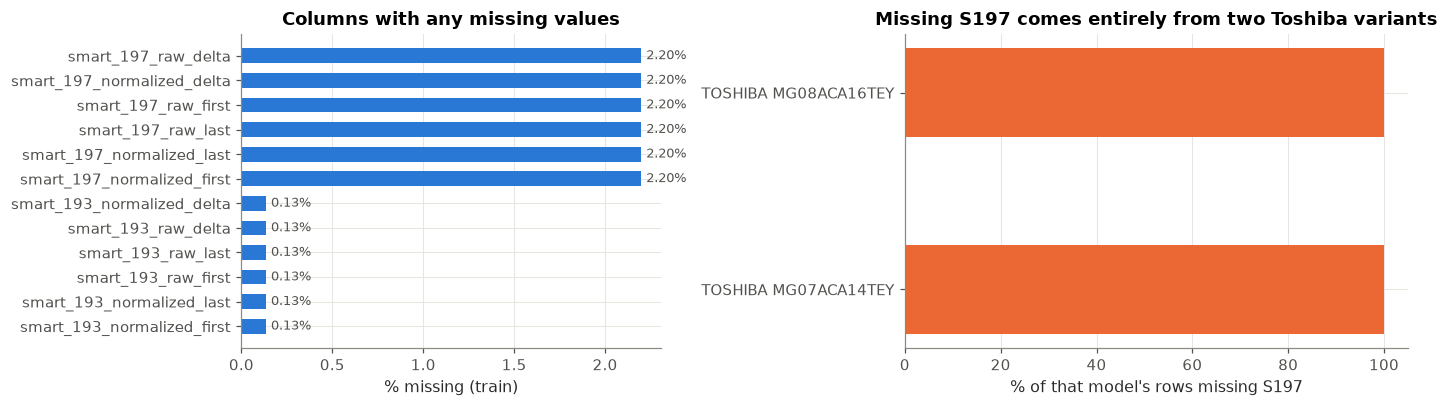

,S197 missing,S197 % missing,S193 missing,S193 % missing
model,,,,
TOSHIBA MG08ACA16TEY,3397,100.0%,0,0.0%
TOSHIBA MG07ACA14TEY,333,100.0%,0,0.0%
ST500LM012 HN,0,0.0%,225,100.0%


In [39]:
na = train.isna().mean()
na = na[na > 0].sort_values()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1, 1.2]})
axes[0].barh(na.index, na.values * 100, color=SERIES[0], height=0.6)
axes[0].set_xlabel("% missing (train)"); axes[0].set_title("Columns with any missing values")
for y, v in enumerate(na.values * 100): axes[0].text(v + 0.03, y, f"{v:.2f}%", va="center", fontsize=8.5, color="#52514e")

miss_by_model = (train.assign(m197=train.smart_197_raw_last.isna(), m193=train.smart_193_raw_last.isna())
                 .groupby("model")[["m197", "m193"]].agg(["sum", "mean"]))
miss_by_model.columns = ["S197 missing", "S197 % missing", "S193 missing", "S193 % missing"]
top = miss_by_model[miss_by_model["S197 missing"] > 0].sort_values("S197 missing", ascending=False)
axes[1].barh(top.index[::-1], top["S197 % missing"][::-1] * 100, color=SERIES[1], height=0.45)
axes[1].set_xlabel("% of that model's rows missing S197"); axes[1].set_title("Missing S197 comes entirely from two Toshiba variants")
plt.tight_layout(); plt.show()
display(miss_by_model[(miss_by_model["S197 missing"] > 0) | (miss_by_model["S193 missing"] > 0)]
        .sort_values("S197 missing", ascending=False).head(10)
        .style.format({"S197 % missing": "{:.1%}", "S193 % missing": "{:.1%}"}))

**Interpretation.**

We come to a conclusion that there is very little missing values, and the missing values are not random. Every missing value for 197 is due to Toshiba and its variants. And every missing 193 value is due to a single model ST500LM012 HN. As the missingness is due to specific models we can not interpolatre these values. What we can do is label them as NaN or interpolate them but or add a attribute not repoted label.

### 3.2 Coverage over time and drive overlap between splits

Here we are finding out that over 30 day periods how many logs were made and how mau drives have multiple logs in different windows. Thius helpos us confirm the the splits are time based, and a same drive can be in the train and test set but in different time windows. This will help test the model on the drives it has already seen but in different time windows.

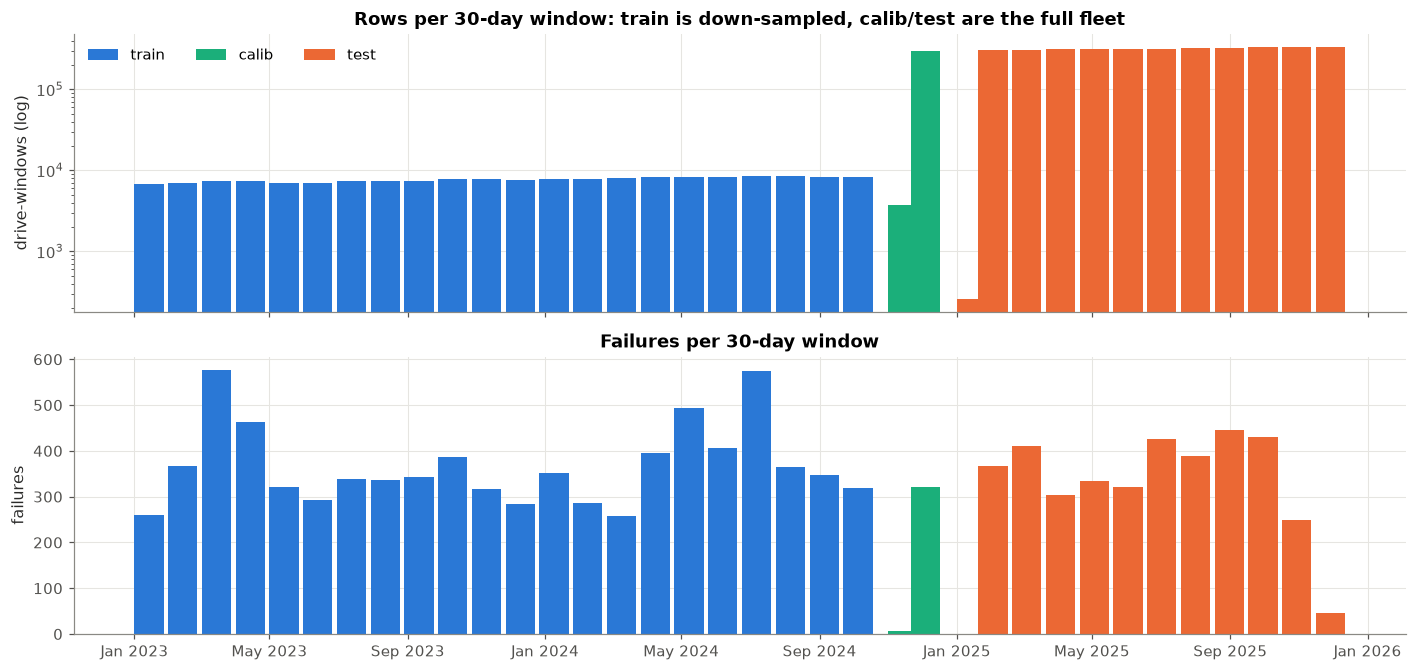

,train ∩ calib,train ∩ test,calib ∩ test,test drives never seen in train,share of test drives seen in train
unique serials,"113,373","113,178","292,547","230,845",32.9%


In [40]:
cov = pd.concat([d.groupby("window").agg(rows=("label", "size"), failures=("label", "sum"),
                                         start=("window_first_date", "min")).assign(split=k)
                 for k, d in DFS.items()]).reset_index()
fig, axes = plt.subplots(2, 1, figsize=(13, 6.2), sharex=True)
for k in SPLITS:
    c = cov[cov.split == k]
    axes[0].bar(c.start, c.rows, width=26, color=SPLIT_COL[k], label=k, align="edge")
    axes[1].bar(c.start, c.failures, width=26, color=SPLIT_COL[k], label=k, align="edge")
axes[0].set_yscale("log"); axes[0].set_ylabel("drive-windows (log)")
axes[0].set_title("Rows per 30-day window: train is down-sampled, calib/test are the full fleet")
axes[0].legend(ncol=3, loc="upper left")
axes[1].set_ylabel("failures"); axes[1].set_title("Failures per 30-day window")
axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
plt.tight_layout(); plt.show()

s = {k: set(d.serial_number.unique()) for k, d in DFS.items()}
ov = pd.DataFrame({
    "train ∩ calib": [len(s["train"] & s["calib"])],
    "train ∩ test": [len(s["train"] & s["test"])],
    "calib ∩ test": [len(s["calib"] & s["test"])],
    "test drives never seen in train": [len(s["test"] - s["train"])],
    "share of test drives seen in train": [len(s["test"] & s["train"]) / len(s["test"])],
}, index=["unique serials"])
display(ov.style.format({c: "{:,}" for c in ov.columns[:-1]} | {"share of test drives seen in train": "{:.1%}"}))

**Interpretation.**
Train has about 7–8k down-sampled rows per window. Calib and test have about 300–335k rows per window, which is the full fleet. Every split has a few hundred failures per window, because down-sampling only removed healthy rows. A total of 113k drives appear in both the train and test sets and 67% of the drives in test do not appear in train, meaning that the model has to generalize in these new drives rather than just traking the serial number, making for a more accurate model.

---
## 4. Statistical Analysis 1: Class Imbalance and the Train → Test Prior Shift

Here we are examning the failure rate in each split with the 95% wilson confidence interval on each window. As teh failures are very rare in the orignale data, the train set was rebalnced. A modle trained on the 1:20 ratio give out a lot of falso negatives, and if a modle was to predict a drive not to fail for all test data that it would get a accuarcy of 99%, which is misleading. Here we will show that the predicted probabilitie will need recalibration.

In [41]:
rows = []
for k in SPLITS:
    d = DFS[k]; n, kpos = len(d), int(d.label.sum())
    p, lo, hi = wilson(kpos, n)
    rows.append({"split": k, "n": n, "failures": kpos, "failure rate": p, "95% CI low": lo, "95% CI high": hi,
                 "imbalance (neg:pos)": f"{(n-kpos)/kpos:,.0f} : 1"})
imb = pd.DataFrame(rows).set_index("split")

# Undo the 20:1 down-sampling: each train negative stands for 20 real negatives
w_neg = 20
train_reweighted = train.label.sum() / (train.label.sum() + w_neg * (train.label == 0).sum())
display(imb.style.format({"n": "{:,}", "failures": "{:,}", "failure rate": "{:.3%}", "95% CI low": "{:.3%}", "95% CI high": "{:.3%}"}))
print(f"Train rate after undoing the down-sampling: {train_reweighted:.3%}  |  test/train prevalence ratio: {imb.loc['train','failure rate']/imb.loc['test','failure rate']:.0f}×")

# Annualised failure rate (Backblaze definition) on the natural-prevalence splits
for k in ["calib", "test"]:
    d = DFS[k]
    afr = d.label.sum() / (d.days_observed.sum() / 365)
    print(f"{k:>5} annualised failure rate (AFR) = failures / drive-years = {afr:.2%}")

,n,failures,failure rate,95% CI low,95% CI high,imbalance (neg:pos)
split,,,,,,
train,"169,827","8,087",4.762%,4.662%,4.864%,20 : 1
calib,"297,009",328,0.110%,0.099%,0.123%,905 : 1
test,"3,521,973","3,722",0.106%,0.102%,0.109%,945 : 1


Train rate after undoing the down-sampling: 0.249%  |  test/train prevalence ratio: 45×
calib annualised failure rate (AFR) = failures / drive-years = 1.36%
 test annualised failure rate (AFR) = failures / drive-years = 1.30%


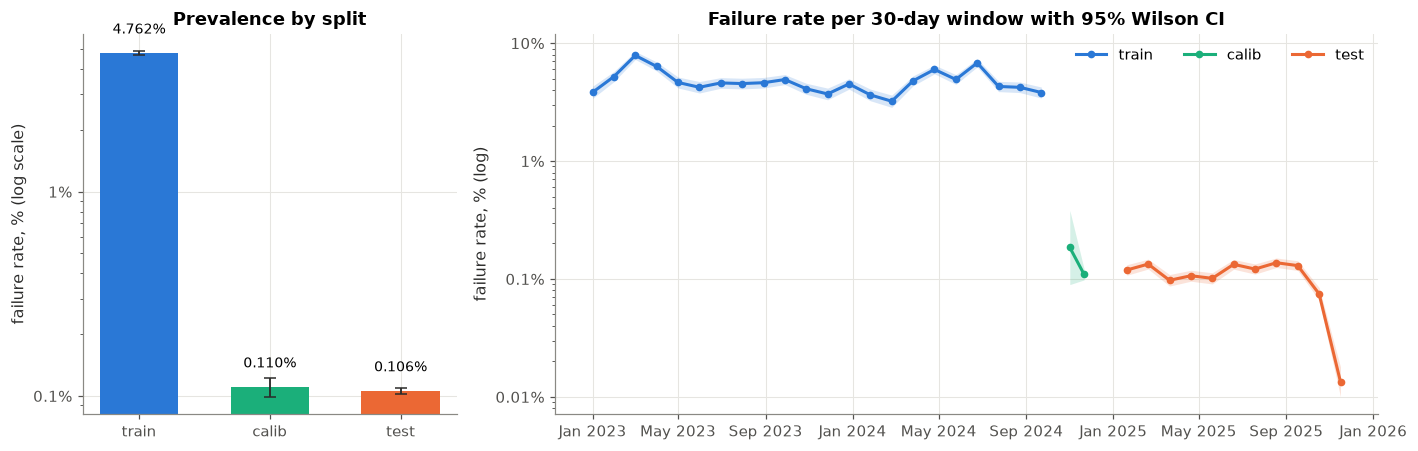

Test: χ² homogeneity of failure rate across 11 windows: χ²=411.2, dof=10, p=3.89e-82
      excluding the final (right-censored) window: χ²=103.0, dof=9, p=3.89e-18


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 2.2]})
ax = axes[0]
x = np.arange(3)
ax.bar(x, imb["failure rate"] * 100, color=[SPLIT_COL[k] for k in SPLITS], width=0.6)
ax.errorbar(x, imb["failure rate"] * 100, yerr=[(imb["failure rate"] - imb["95% CI low"]) * 100, (imb["95% CI high"] - imb["failure rate"]) * 100],
            fmt="none", ecolor="#2b2b2a", capsize=4, lw=1.2)
ax.set_yscale("log"); ax.set_xticks(x, SPLITS); ax.set_ylabel("failure rate, % (log scale)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}%"))
for xi, v in zip(x, imb["failure rate"] * 100): ax.text(xi, v * 1.25, f"{v:.3f}%", ha="center", fontsize=9)
ax.set_title("Prevalence by split")

ax = axes[1]
for k in SPLITS:
    g = DFS[k].groupby("window").agg(n=("label", "size"), k=("label", "sum"), t=("window_first_date", "min"))
    g = g[g.n > 1000]
    p, lo, hi = wilson(g.k, g.n)
    ax.plot(g.t, p * 100, "-o", ms=4, color=SPLIT_COL[k], label=k)
    ax.fill_between(g.t, lo * 100, hi * 100, color=SPLIT_COL[k], alpha=0.18, lw=0)
ax.set_yscale("log"); ax.set_ylabel("failure rate, % (log)"); ax.legend(ncol=3)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}%"))
ax.set_title("Failure rate per 30-day window with 95% Wilson CI")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
plt.tight_layout(); plt.show()

# Is the monthly failure rate stable within test? Chi-square test of homogeneity across windows
g = test.groupby("window").label.agg(["sum", "size"]); g = g[g["size"] > 1000]
chi2, pval, dof, _ = stats.chi2_contingency(np.c_[g["sum"], g["size"] - g["sum"]])
print(f"Test: χ² homogeneity of failure rate across {len(g)} windows: χ²={chi2:.1f}, dof={dof}, p={pval:.2e}")
g2 = g.iloc[:-1]
chi2b, pvalb, dofb, _ = stats.chi2_contingency(np.c_[g2["sum"], g2["size"] - g2["sum"]])
print(f"      excluding the final (right-censored) window: χ²={chi2b:.1f}, dof={dofb}, p={pvalb:.2e}")

**Interpretation.**
There is a sever imbalance. Train is 1 failure : 20 healthy (4.76%). Calib and test are about 1 : 900 (0.11%). A classifier tarined on this data will over predict failure. To counter this we need to take into accoutn PR-AUC or set a false alarm rate.

---
## 5. Statistical Analysis 2: Who Fails? Manufacturer, Model and Age

In this section we calculate annual faliure rate (afr) for all the manufacturers, and for the 15 most common drive models. We also check if failure is independant of teh model and plot afr against drive age. Thsi will help us determine if the failure is dependant on the model, because if it is then there shoupd be equal representation of all models in the train test split. The afr by age graph will help us determine if failure also depends on the age of the drive. 

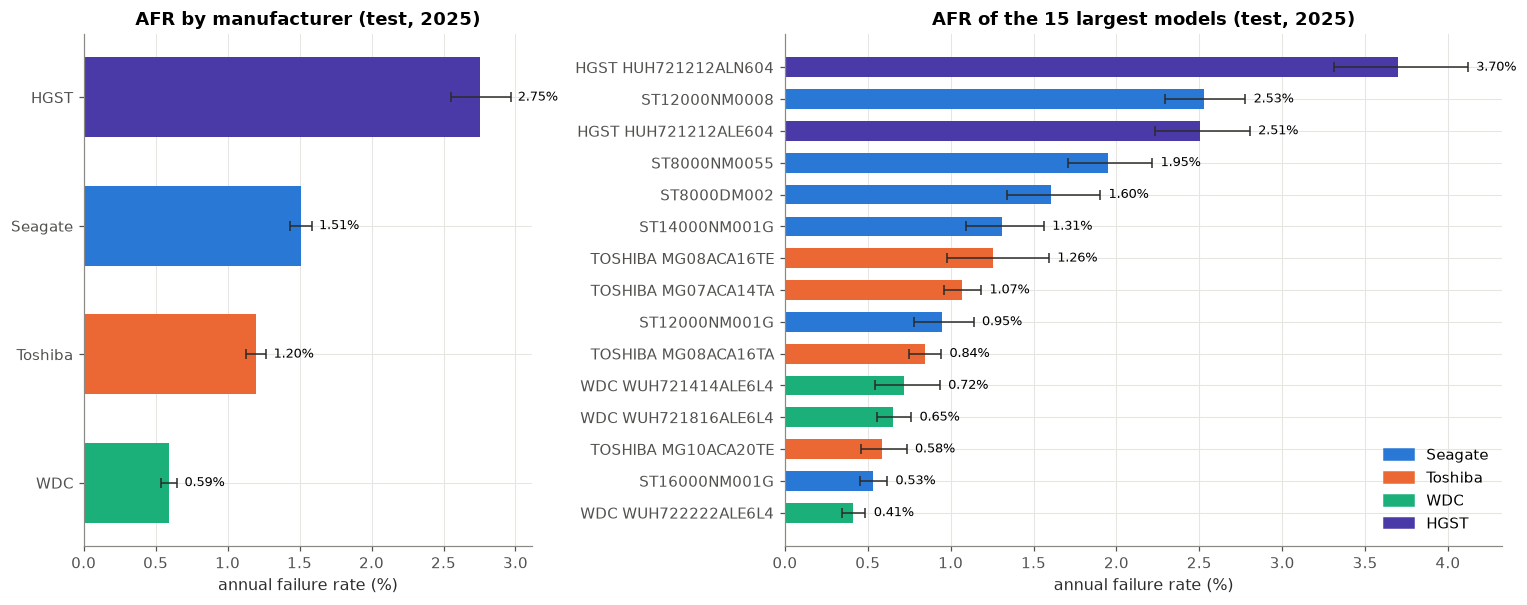

,drives,failures,drive_years,AFR,AFR_lo,AFR_hi
vendor,,,,,,
WDC,"84,369",404,"68,486",0.59%,0.53%,0.65%
Toshiba,"114,034","1,130","94,372",1.20%,1.13%,1.27%
Seagate,"113,682","1,499","99,501",1.51%,1.43%,1.58%
HGST,"31,938",689,"25,033",2.75%,2.55%,2.97%


χ² test of independence (model × failure, 19 models): χ²=2,522.9, dof=18, p=0.0e+00, Cramér's V=0.027


In [43]:
def afr_table(d, by):
    g = d.groupby(by).agg(failures=("label", "sum"), drive_days=("days_observed", "sum"), drives=("serial_number", "nunique"))
    g["drive_years"] = g.drive_days / 365
    g["AFR"] = g.failures / g.drive_years
    # exact Poisson CI for the failure count
    g["AFR_lo"] = stats.chi2.ppf(0.025, 2 * g.failures) / 2 / g.drive_years
    g["AFR_hi"] = stats.chi2.ppf(0.975, 2 * (g.failures + 1)) / 2 / g.drive_years
    return g.fillna(0)

afr_v = afr_table(test, "vendor").sort_values("AFR")
afr_m = afr_table(test, "model").sort_values("drive_years", ascending=False).head(15).sort_values("AFR")
afr_m["vendor"] = afr_m.index.map(vendor)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [1, 1.6]})
for ax, t, title in [(axes[0], afr_v, "AFR by manufacturer (test, 2025)"), (axes[1], afr_m, "AFR of the 15 largest models (test, 2025)")]:
    cols = [VENDOR_COL[v] for v in (t.index if t is afr_v else t.vendor)]
    y = np.arange(len(t))
    ax.barh(y, t.AFR * 100, color=cols, height=0.62)
    ax.errorbar(t.AFR * 100, y, xerr=[(t.AFR - t.AFR_lo) * 100, (t.AFR_hi - t.AFR) * 100], fmt="none", ecolor="#2b2b2a", capsize=3, lw=1)
    ax.set_yticks(y, t.index); ax.set_xlabel("annual failure rate (%)"); ax.set_title(title)
    for yi, (v, hi) in enumerate(zip(t.AFR * 100, t.AFR_hi * 100)): ax.text(hi + 0.05, yi, f"{v:.2f}%", va="center", fontsize=8.5)
handles = [plt.Rectangle((0, 0), 1, 1, color=VENDOR_COL[v]) for v in ["Seagate", "Toshiba", "WDC", "HGST"]]
axes[1].legend(handles, ["Seagate", "Toshiba", "WDC", "HGST"], loc="lower right")
plt.tight_layout(); plt.show()

display(afr_v[["drives", "failures", "drive_years", "AFR", "AFR_lo", "AFR_hi"]]
        .style.format({"drives": "{:,}", "failures": "{:,}", "drive_years": "{:,.0f}", "AFR": "{:.2%}", "AFR_lo": "{:.2%}", "AFR_hi": "{:.2%}"}))

# Independence test: model × label (models with ≥ 20,000 windows)
big = test.model.value_counts(); big = big[big >= 20000].index
ct = pd.crosstab(test.loc[test.model.isin(big), "model"], test.loc[test.model.isin(big), "label"])
chi2, p, dof, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"χ² test of independence (model × failure, {len(big)} models): χ²={chi2:,.1f}, dof={dof}, p={p:.1e}, Cramér's V={cramers_v:.3f}")

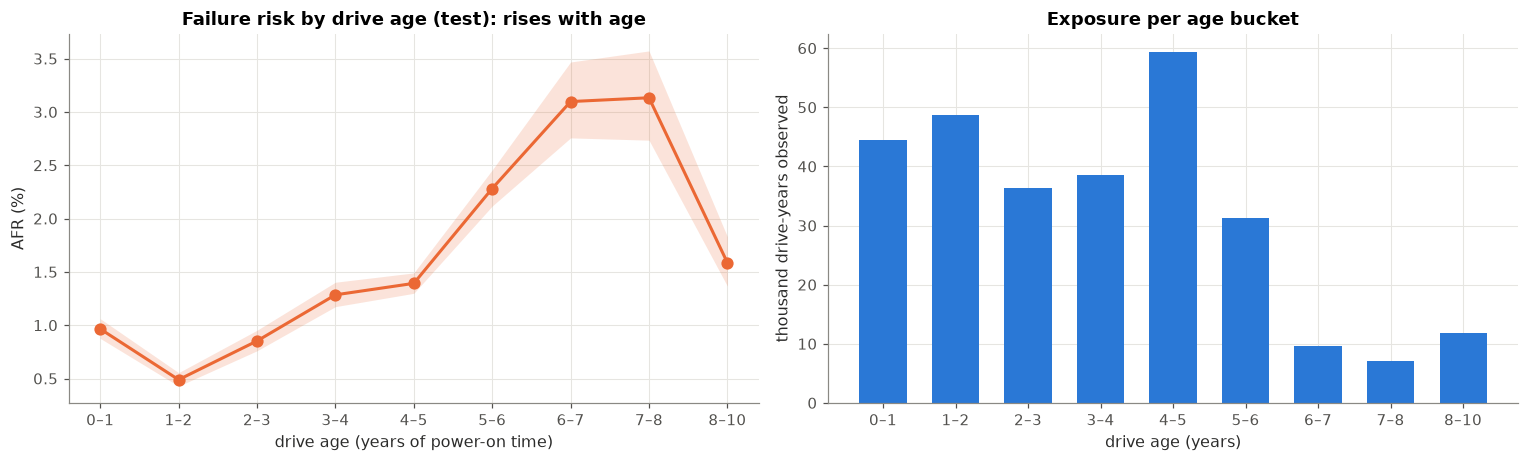

,drives,failures,AFR,AFR_lo,AFR_hi
capacity (TB),,,,,
8,"24,041",402,1.87%,1.69%,2.06%
12,"60,901","1,238",2.29%,2.16%,2.42%
14,"59,786",620,1.16%,1.07%,1.26%
16,"117,124","1,048",1.01%,0.95%,1.07%
20,"18,072",72,0.58%,0.46%,0.73%
22,"44,537",139,0.41%,0.35%,0.49%
24,"12,140",146,2.56%,2.16%,3.01%


In [44]:
# Failure risk vs age (power-on hours → years)
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 14]
d = test.dropna(subset=["age_years"]).copy()
d["age_bin"] = pd.cut(d.age_years, bins, right=False)
age = afr_table(d, "age_bin")
age = age[age.drive_years > 500]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
ax = axes[0]
xl = [f"{int(i.left)}–{int(i.right)}" for i in age.index]
ax.plot(xl, age.AFR * 100, "-o", color=FAILED, ms=7)
ax.fill_between(xl, age.AFR_lo * 100, age.AFR_hi * 100, color=FAILED, alpha=0.18, lw=0)
ax.set_xlabel("drive age (years of power-on time)"); ax.set_ylabel("AFR (%)")
ax.set_title("Failure risk by drive age (test): rises with age")
ax2 = axes[1]
ax2.bar(xl, age.drive_years / 1e3, color=HEALTHY, width=0.65)
ax2.set_xlabel("drive age (years)"); ax2.set_ylabel("thousand drive-years observed"); ax2.set_title("Exposure per age bucket")
plt.tight_layout(); plt.show()

# Capacity
cap = afr_table(test, "capacity_tb"); cap = cap[cap.drive_years > 1000]
cap.index = cap.index.astype(int)
display(cap[["drives", "failures", "AFR", "AFR_lo", "AFR_hi"]].rename_axis("capacity (TB)")
        .style.format({"drives": "{:,}", "failures": "{:,}", "AFR": "{:.2%}", "AFR_lo": "{:.2%}", "AFR_hi": "{:.2%}"}))

**Interpretation.**
The results show that manufacturers matter a lot in drive failure rates. In 2025 HGST had a drive failure rate of 2.75% wich is maro than double that of toshiba. We can aslo conclude tht the modle of the drive also plays a crucial role in its failure as the X^2 test of independance also reject the "failure does not depend on model".

---
## 6. Statistical Analysis 3: SMART Signatures of Failing vs Healthy Drives

In ths section we check how different the failing values of the 14 SMART attributes are to teh healthy ones. We check the % on non-zero values by class and the odds ration of filure with non-zero values. We check theese becase most healthy drives have 0 errors. This will help tell us which attribute can carry the failure signal and what trend will the failure signal have.

In [45]:

y = train.label.values
res = []

for i in SMART_IDS:
    c = f"smart_{i}_raw_last"
    x = train[c].values.astype(float)
    m = ~np.isnan(x)

    xf, xh = x[m & (y == 1)], x[m & (y == 0)]

    nz_f, nz_h = (xf > 0).mean(), (xh > 0).mean()

    # Odds ratio of failure given non-zero (Haldane-Anscombe correction)
    a, b = (xf > 0).sum() + .5, (xf == 0).sum() + .5
    c_, d_ = (xh > 0).sum() + .5, (xh == 0).sum() + .5

    OR = (a * d_) / (b * c_)
    se = np.sqrt(1/a + 1/b + 1/c_ + 1/d_)

    # Keep only the non-zero odds ratio and descriptive statistics
    res.append({
        "attribute": sname(i),
        "median healthy": np.median(xh),
        "median failed": np.median(xf),
        "% non-zero healthy": nz_h,
        "% non-zero failed": nz_f,
        "odds ratio (non-zero)": OR,
        "OR 95% CI": (
            f"{np.exp(np.log(OR)-1.96*se):.1f}–"
            f"{np.exp(np.log(OR)+1.96*se):.1f}"
        )
    })

sig = pd.DataFrame(res).set_index("attribute")

# An odds ratio for "non-zero" is meaningless for counters
# that are almost always non-zero
always = sig["% non-zero healthy"] > 0.95
sig.loc[always, "odds ratio (non-zero)"] = np.nan
sig.loc[always, "OR 95% CI"] = "n/a (always > 0)"

display(
    sig.style.format({
        "median healthy": "{:,.0f}",
        "median failed": "{:,.0f}",
        "% non-zero healthy": "{:.1%}",
        "% non-zero failed": "{:.1%}",
        "odds ratio (non-zero)": lambda v: (
            "n/a" if pd.isna(v) else f"{v:,.2f}"
        )
    })
)

,median healthy,median failed,% non-zero healthy,% non-zero failed,odds ratio (non-zero),OR 95% CI
attribute,,,,,,
S1 Read Error Rate,0,"23,744,184",42.1%,57.3%,1.84,1.8–1.9
S3 Spin-Up Time,149,0,50.4%,35.3%,0.54,0.5–0.6
S4 Start/Stop Count,9,12,100.0%,100.0%,n/a,n/a (always > 0)
S5 Reallocated Sectors,0,0,3.4%,47.9%,25.92,24.6–27.3
S7 Seek Error Rate,0,"101,217,298",42.0%,54.8%,1.67,1.6–1.7
S9 Power-On Hours,"25,125","33,996",100.0%,100.0%,n/a,n/a (always > 0)
S10 Spin Retry Count,0,0,0.0%,0.0%,0.33,0.0–5.4
S12 Power Cycle Count,9,12,100.0%,100.0%,n/a,n/a (always > 0)
S192 Power-Off Retract Count,8,12,87.7%,89.9%,1.24,1.2–1.3


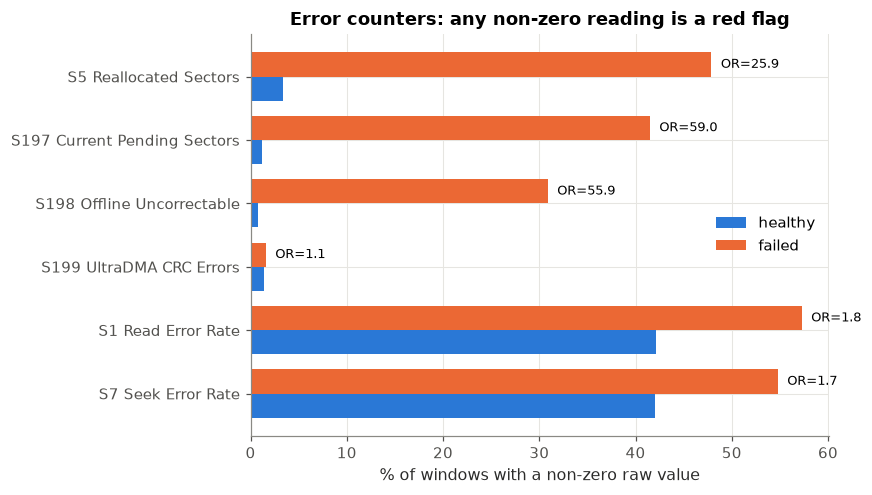

In [46]:
ERR = [5, 197, 198, 199, 1, 7]
fig, ax = plt.subplots(figsize=(8, 4.6))
labels = [sname(i) for i in ERR]
yy = np.arange(len(ERR)); h = 0.38
ax.barh(yy + h/2, sig.loc[labels, "% non-zero healthy"] * 100, h, color=HEALTHY, label="healthy")
ax.barh(yy - h/2, sig.loc[labels, "% non-zero failed"] * 100, h, color=FAILED, label="failed")
for yi, lab in zip(yy, labels):
    ax.text(sig.loc[lab, "% non-zero failed"] * 100 + 1, yi - h/2, f'OR={sig.loc[lab, "odds ratio (non-zero)"]:.1f}', va="center", fontsize=8.5)
ax.set_yticks(yy, labels); ax.invert_yaxis(); ax.set_xlabel("% of windows with a non-zero raw value")
ax.set_title("Error counters: any non-zero reading is a red flag")
ax.legend(loc="center right")

plt.tight_layout(); plt.show()

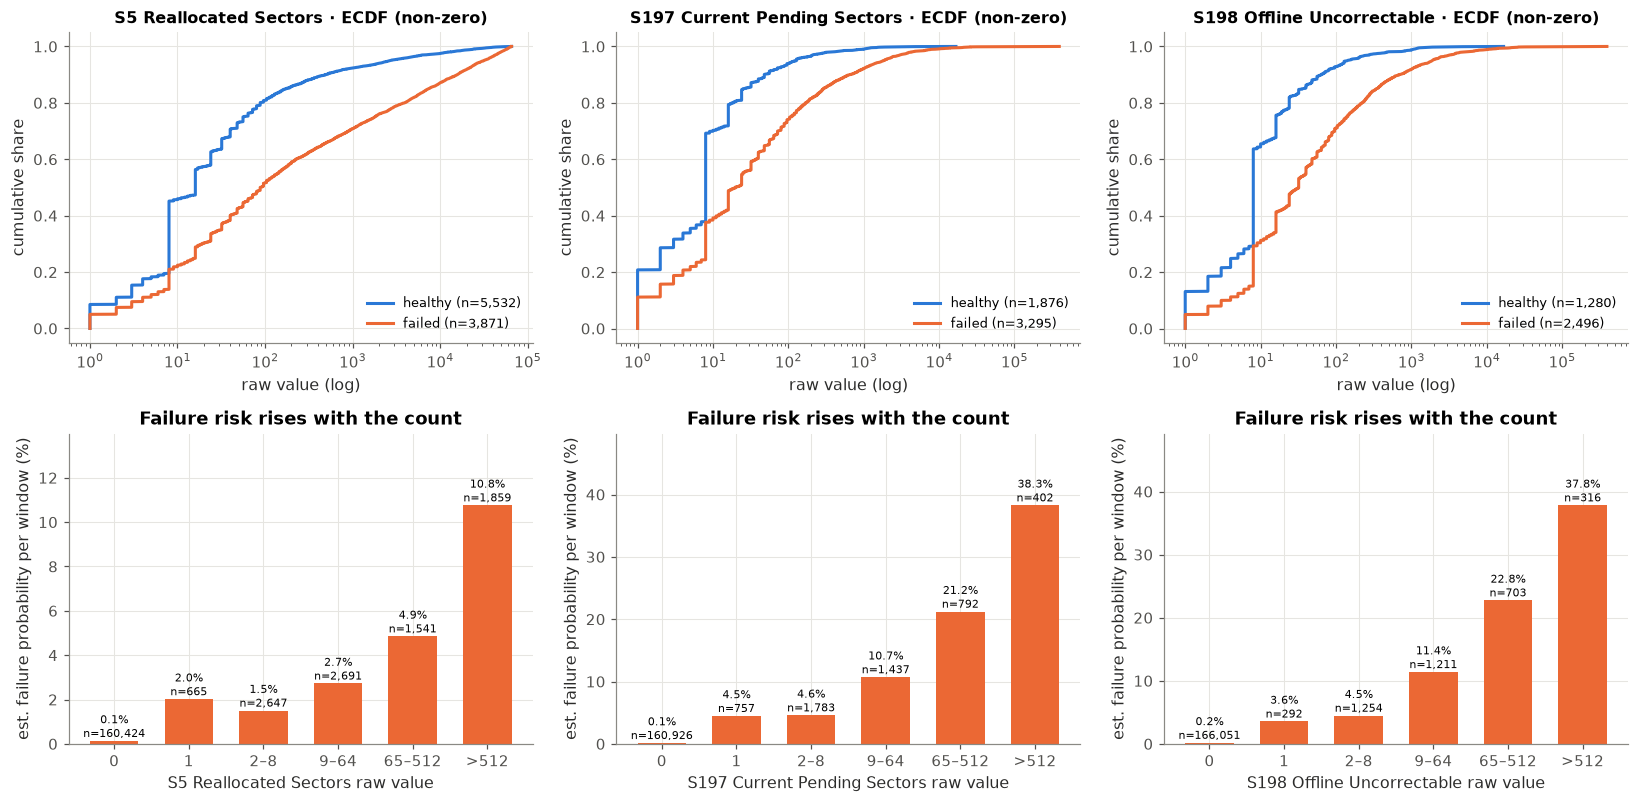

In [47]:
# Distribution shape for the three strongest precursors: ECDF on log scale (non-zero part) + P(fail | value bucket)
fig, axes = plt.subplots(2, 3, figsize=(15, 7.4))
for j, i in enumerate([5, 197, 198]):
    c = f"smart_{i}_raw_last"
    ax = axes[0, j]
    for lab, col, nm in [(0, HEALTHY, "healthy"), (1, FAILED, "failed")]:
        v = train.loc[(train.label == lab) & (train[c] > 0), c].sort_values()
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=col, label=f"{nm} (n={len(v):,})")
    ax.set_xscale("log"); ax.set_title(f"{sname(i)} · ECDF (non-zero)", fontsize=10.5); ax.set_xlabel("raw value (log)"); ax.set_ylabel("cumulative share")
    ax.legend(loc="lower right", fontsize=8.5)

    ax = axes[1, j]
    bucket = pd.cut(train[c], [-0.5, 0.5, 1.5, 8.5, 64.5, 512.5, np.inf], labels=["0", "1", "2–8", "9–64", "65–512", ">512"])
    g = train.groupby(bucket, observed=True).label.agg(["sum", "size"])
    # convert back to natural prevalence by re-weighting negatives ×20
    nat = g["sum"] / (g["sum"] + 20 * (g["size"] - g["sum"]))
    ax.bar(g.index.astype(str), nat * 100, color=FAILED, width=0.65)
    for xi, (v, n) in enumerate(zip(nat * 100, g["size"])): ax.text(xi, v, f"{v:.1f}%\nn={n:,}", ha="center", va="bottom", fontsize=7.5)
    ax.set_ylabel("est. failure probability per window (%)"); ax.set_xlabel(f"{sname(i)} raw value")
    ax.set_title("Failure risk rises with the count"); ax.set_ylim(0, nat.max() * 100 * 1.3)
plt.tight_layout(); plt.show()

**Interpretation.**
S5, S197, S198 are the three most dominate precursors. For health drives 3.4%, 1.2%, 0.8%  have non zero values respectively and for thr failed drive the percentage of non zero values increase to 47.9%, 41.5%, 30.9% respectively. The counts also matter as we see the probability of failure increases as the count also increases for these SMART attributes. However teh data also shows about half of broken drives gave no warning in S5 at all. Some drives just die suddenly.

---
## 7. Statistical Analysis 4: Raw vs Normalized SMART Values (What Normalization Does)

Every SMART attribute has a RAW and a NORMALIZED value. The RAW value is the physical value of the drive while teh normalized value is a 1–253 score that the vendor's firmware derives from the raw value using a formula the vendor does not publish. The purpose of normalization is to put every attribute on a common "health" scale, where 100 (or 200) means new and a falling value means degradation. In this section we test whether that normalization helps or hurts prediction. This will help us determine wich of the SMART columns to keep and how do we scale them.

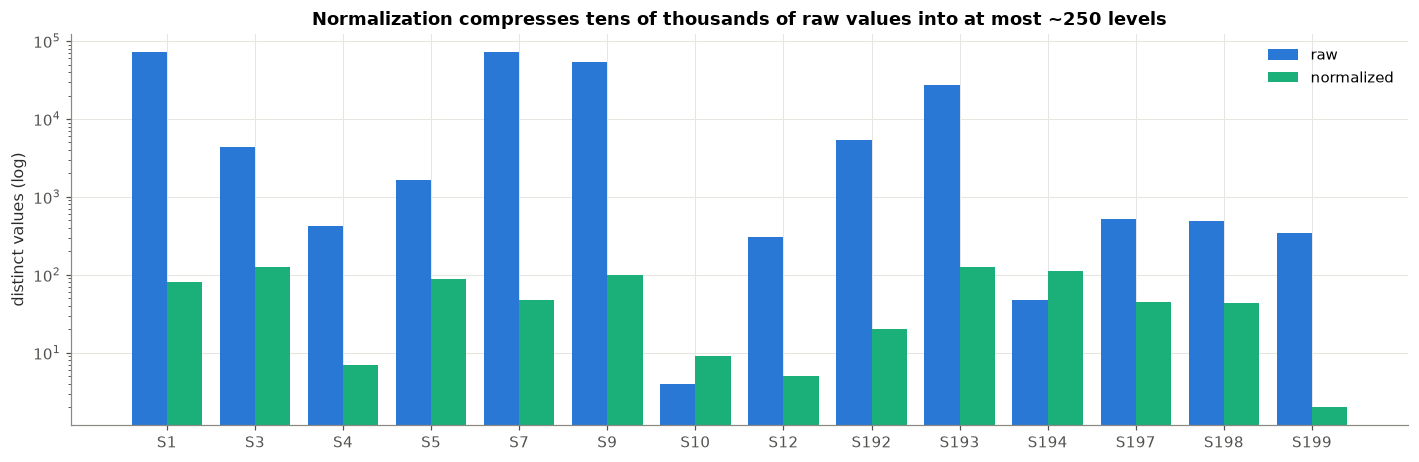

,distinct raw,distinct normalized,raw: share at mode,normalized: share at mode,normalized range,compression (raw/normalized)
attribute,,,,,,
S1 Read Error Rate,"72,495",80,57.1%,57.7%,1–200,906×
S3 Spin-Up Time,"4,432",127,50.3%,36.6%,80–253,35×
S4 Start/Stop Count,420,7,7.6%,99.9%,75–100,60×
S5 Reallocated Sectors,"1,636",89,94.5%,99.0%,1–252,18×
S7 Seek Error Rate,"72,332",48,57.4%,57.2%,36–252,"1,507×"
S9 Power-On Hours,"53,344",100,0.0%,5.7%,1–100,533×
S10 Spin Retry Count,4,9,100.0%,99.8%,90–252,0×
S12 Power Cycle Count,303,5,7.6%,100.0%,83–100,61×
S192 Power-Off Retract Count,"5,394",20,12.2%,93.2%,73–252,270×


In [48]:
# 4.1 Information content: distinct values & share of rows at the most common value
info = []
for i in SMART_IDS:
    r, n = train[f"smart_{i}_raw_last"], train[f"smart_{i}_normalized_last"]
    info.append({"attribute": sname(i), "distinct raw": r.nunique(), "distinct normalized": n.nunique(),
                 "raw: share at mode": (r == r.mode()[0]).mean(), "normalized: share at mode": (n == n.mode()[0]).mean(),
                 "normalized range": f"{n.min():.0f}–{n.max():.0f}"})
info = pd.DataFrame(info).set_index("attribute")
info["compression (raw/normalized)"] = info["distinct raw"] / info["distinct normalized"]

fig, ax = plt.subplots(figsize=(13, 4.3))
x = np.arange(len(info)); w = 0.4
ax.bar(x - w/2, info["distinct raw"], w, color=SERIES[0], label="raw")
ax.bar(x + w/2, info["distinct normalized"], w, color=SERIES[2], label="normalized")
ax.set_yscale("log"); ax.set_xticks(x, [s.split(" ", 1)[0] for s in info.index]); ax.set_ylabel("distinct values (log)")
ax.set_title("Normalization compresses tens of thousands of raw values into at most ~250 levels"); ax.legend()
plt.tight_layout(); plt.show()
display(info.style.format({"distinct raw": "{:,}", "distinct normalized": "{:,}", "raw: share at mode": "{:.1%}",
                           "normalized: share at mode": "{:.1%}", "compression (raw/normalized)": "{:,.0f}×"}))

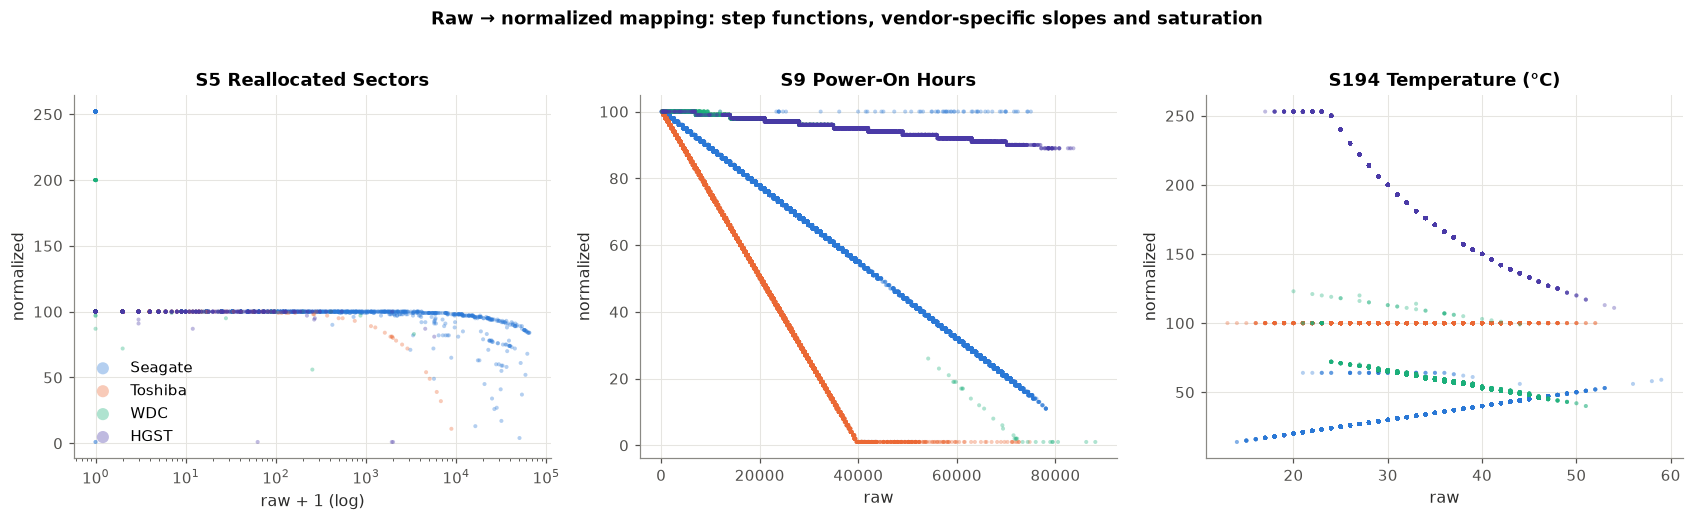

In [49]:
# 4.2 The raw → normalized mapping, coloured by vendor
samp = train.sample(40000, random_state=7)
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
for ax, i, xlog in zip(axes, [5, 9, 194], [True, False, False]):
    for v in ["Seagate", "Toshiba", "WDC", "HGST"]:
        s = samp[samp.vendor == v]
        xr = s[f"smart_{i}_raw_last"] + (1 if xlog else 0)
        ax.scatter(xr, s[f"smart_{i}_normalized_last"], s=7, alpha=0.35, color=VENDOR_COL[v], label=v, edgecolors="none")
    if xlog: ax.set_xscale("log"); ax.set_xlabel("raw + 1 (log)")
    else: ax.set_xlabel("raw")
    ax.set_ylabel("normalized"); ax.set_title(sname(i))
axes[0].legend(markerscale=3, loc="lower left")
fig.suptitle("Raw → normalized mapping: step functions, vendor-specific slopes and saturation", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

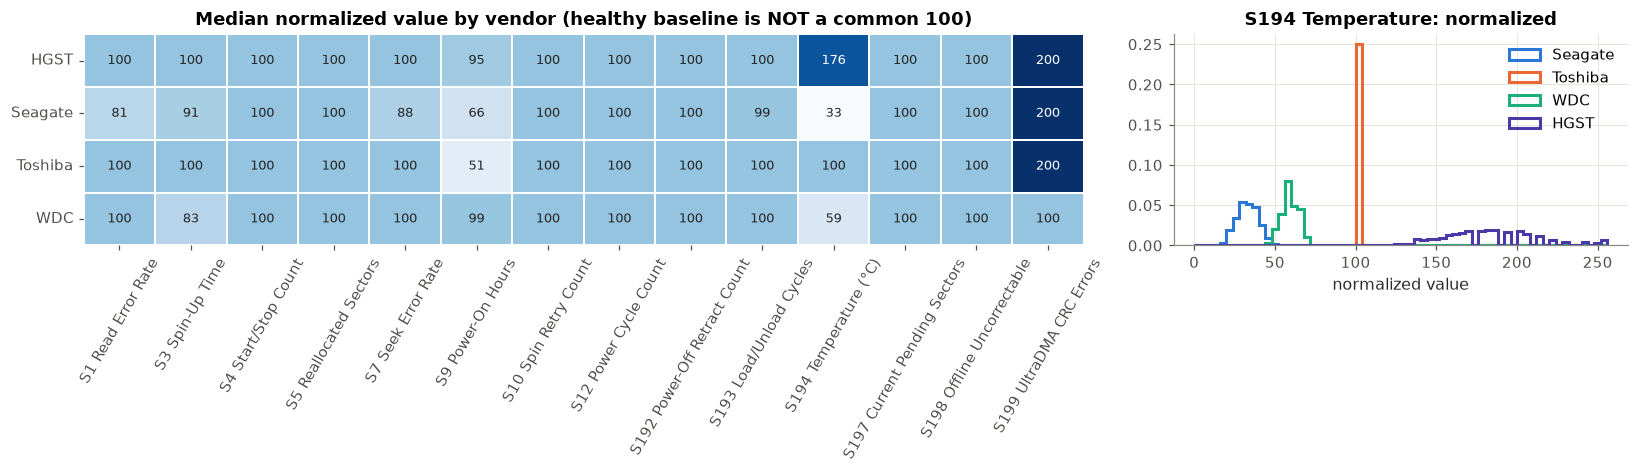

Healthy drives, S194 by vendor -> median raw °C: {'HGST': 33.0, 'Seagate': 32.0, 'Toshiba': 33.0, 'WDC': 35.0} | median normalized: {'HGST': 181.0, 'Seagate': 32.0, 'Toshiba': 100.0, 'WDC': 59.0}
Kruskal–Wallis H (raw °C) = 5,247   vs   H (normalized) = 147,962


In [50]:
# 4.3 Vendor dependence: the same "normalized" score means different things per manufacturer
vend = train[train.vendor != "Other"]
med = vend.groupby("vendor")[[f"smart_{i}_normalized_last" for i in SMART_IDS]].median()
med.columns = [sname(i) for i in SMART_IDS]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4), gridspec_kw={"width_ratios": [2.2, 1]})
sns.heatmap(med, annot=True, fmt=".0f", cmap="Blues", cbar=False, ax=axes[0], linewidths=1, linecolor="white", annot_kws={"fontsize": 8.5})
axes[0].set_title("Median normalized value by vendor (healthy baseline is NOT a common 100)"); axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=60); axes[0].tick_params(axis="y", rotation=0); axes[0].set_ylabel("")

for v in ["Seagate", "Toshiba", "WDC", "HGST"]:
    s = vend[vend.vendor == v]
    axes[1].hist(s.smart_194_normalized_last, bins=np.arange(0, 260, 4), histtype="step", lw=2, color=VENDOR_COL[v], label=v, density=True)
axes[1].set_title("S194 Temperature: normalized"); axes[1].set_xlabel("normalized value"); axes[1].legend()
plt.tight_layout(); plt.show()

# Kruskal-Wallis: does the healthy-drive normalized temperature differ by vendor even though raw °C is similar?
h = vend[vend.label == 0]
kw_n = stats.kruskal(*[g.smart_194_normalized_last.dropna() for _, g in h.groupby("vendor")])
kw_r = stats.kruskal(*[g.smart_194_raw_last.dropna() for _, g in h.groupby("vendor")])
print("Healthy drives, S194 by vendor -> median raw °C:", h.groupby("vendor").smart_194_raw_last.median().to_dict(),
      "| median normalized:", h.groupby("vendor").smart_194_normalized_last.median().to_dict())
print(f"Kruskal–Wallis H (raw °C) = {kw_r.statistic:,.0f}   vs   H (normalized) = {kw_n.statistic:,.0f}")

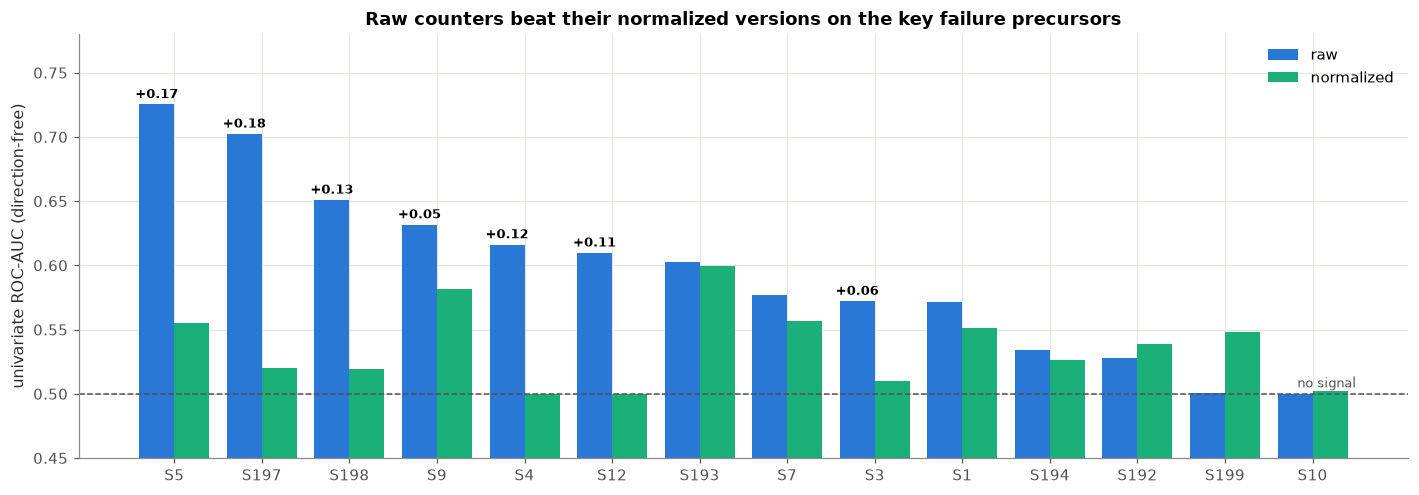

,AUC raw,AUC normalized,Δ (raw − norm),within-vendor AUC raw,within-vendor AUC normalized
attribute,,,,,
S5 Reallocated Sectors,0.725,0.555,0.170,0.696,0.546
S197 Current Pending Sectors,0.702,0.520,0.183,0.696,0.517
S198 Offline Uncorrectable,0.651,0.519,0.132,0.626,0.515
S9 Power-On Hours,0.632,0.581,0.050,0.578,0.579
S4 Start/Stop Count,0.616,0.500,0.116,0.608,0.500
S12 Power Cycle Count,0.610,0.500,0.110,0.602,0.500
S193 Load/Unload Cycles,0.602,0.599,0.003,0.582,0.545
S7 Seek Error Rate,0.577,0.556,0.021,0.525,0.514
S3 Spin-Up Time,0.572,0.510,0.062,0.525,0.559


Wilcoxon signed-rank (raw vs normalized AUC, 14 attributes): W=12, p=0.009; median Δ = +0.036


In [51]:
# 4.4 Predictive power: univariate oriented ROC-AUC, raw vs normalized (pooled and within-vendor)
y = train.label.values
rows = []
for i in SMART_IDS:
    r = oriented_auc(y, train[f"smart_{i}_raw_last"].values.astype(float))
    n = oriented_auc(y, train[f"smart_{i}_normalized_last"].values.astype(float))
    # within-vendor AUC (weighted by vendor size) removes vendor-baseline effects
    wr, wn, ww = [], [], []
    for v, g in train[train.vendor != "Other"].groupby("vendor"):
        if g.label.sum() < 50: continue
        wr.append(oriented_auc(g.label.values, g[f"smart_{i}_raw_last"].values.astype(float)))
        wn.append(oriented_auc(g.label.values, g[f"smart_{i}_normalized_last"].values.astype(float)))
        ww.append(len(g))
    rows.append({"attribute": sname(i), "AUC raw": r, "AUC normalized": n, "Δ (raw − norm)": r - n,
                 "within-vendor AUC raw": np.average(wr, weights=ww), "within-vendor AUC normalized": np.average(wn, weights=ww)})
auc = pd.DataFrame(rows).set_index("attribute").sort_values("AUC raw", ascending=False)

fig, ax = plt.subplots(figsize=(13, 4.6))
x = np.arange(len(auc)); w = 0.4
ax.bar(x - w/2, auc["AUC raw"], w, color=SERIES[0], label="raw")
ax.bar(x + w/2, auc["AUC normalized"], w, color=SERIES[2], label="normalized")
ax.axhline(0.5, color="#52514e", lw=1, ls="--"); ax.text(len(auc) - 0.5, 0.505, "no signal", ha="right", fontsize=8.5, color="#52514e")
ax.set_ylim(0.45, 0.78); ax.set_xticks(x, [s.split(" ", 1)[0] for s in auc.index]); ax.set_ylabel("univariate ROC-AUC (direction-free)")
ax.set_title("Raw counters beat their normalized versions on the key failure precursors"); ax.legend()
for xi, (a, b) in enumerate(zip(auc["AUC raw"], auc["AUC normalized"])):
    if a - b > 0.05: ax.annotate(f"+{a-b:.2f}", (xi - w/2, a + 0.005), ha="center", fontsize=8.5, fontweight="bold")
plt.tight_layout(); plt.show()
display(auc.style.format("{:.3f}").background_gradient(subset=["Δ (raw − norm)"], cmap=DIVERGING, vmin=-0.2, vmax=0.2))

# Paired test across the 14 attributes: is raw systematically more informative?
w_stat, w_p = stats.wilcoxon(auc["AUC raw"], auc["AUC normalized"])
print(f"Wilcoxon signed-rank (raw vs normalized AUC, 14 attributes): W={w_stat:.0f}, p={w_p:.3f}; median Δ = {auc['Δ (raw − norm)'].median():+.3f}")

,skew raw,skew z-score,skew log1p,kurtosis raw,kurtosis log1p,AUC raw,AUC log1p,max |z| (outlier scale),share exactly 0
feature,,,,,,,,,
smart_5_raw_last,21.264,21.264,6.104,513.452,41.232,0.725,0.725,32.651,0.945
smart_197_raw_last,283.549,283.549,8.332,"92,135.500",80.372,0.702,0.702,347.107,0.969
smart_9_raw_last,0.671,0.671,-1.442,-0.432,2.908,0.632,0.632,3.447,0.000
smart_193_raw_last,5.273,5.273,-0.067,61.802,-0.152,0.602,0.602,31.726,0.000
smart_7_raw_last,410.745,410.745,0.323,"169,065.488",-1.866,0.577,0.577,411.638,0.574
smart_1_raw_last,1.175,1.175,0.310,-0.064,-1.885,0.572,0.572,9.015,0.571


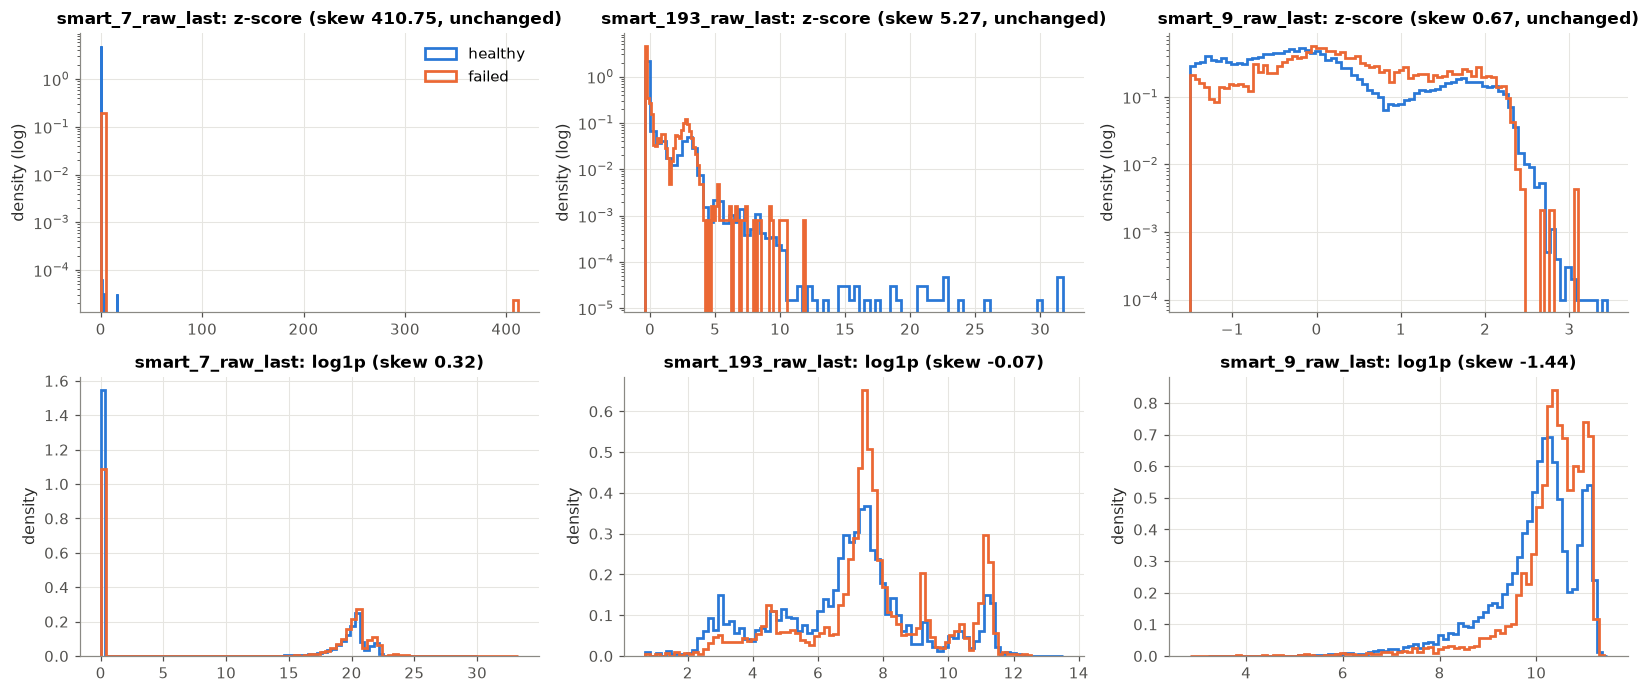

In [52]:
# 4.5 Statistical normalization: what log1p and z-scaling do (and don't do)
feat = ["smart_5_raw_last", "smart_197_raw_last", "smart_9_raw_last", "smart_193_raw_last", "smart_7_raw_last", "smart_1_raw_last"]
rows = []
for c in feat:
    x = train[c].dropna().astype(float)
    z = (x - x.mean()) / x.std()
    lg = np.log1p(x.clip(lower=0))
    rows.append({"feature": c, "skew raw": stats.skew(x), "skew z-score": stats.skew(z), "skew log1p": stats.skew(lg),
                 "kurtosis raw": stats.kurtosis(x), "kurtosis log1p": stats.kurtosis(lg),
                 "AUC raw": oriented_auc(train.loc[x.index, "label"].values, x.values),
                 "AUC log1p": oriented_auc(train.loc[x.index, "label"].values, lg.values),
                 "max |z| (outlier scale)": np.abs(z).max(), "share exactly 0": (x == 0).mean()})
tr = pd.DataFrame(rows).set_index("feature")
display(tr.style.format("{:,.3f}"))

fig, axes = plt.subplots(2, 3, figsize=(15, 6.4))
for j, c in enumerate(["smart_7_raw_last", "smart_193_raw_last", "smart_9_raw_last"]):
    x = train[c].dropna()
    for lab, col, nm in [(0, HEALTHY, "healthy"), (1, FAILED, "failed")]:
        xs = x[train.loc[x.index, "label"] == lab]
        axes[0, j].hist((xs - x.mean()) / x.std(), bins=80, color=col, histtype="step", lw=1.8, density=True, label=nm)
        axes[1, j].hist(np.log1p(xs.clip(lower=0)), bins=80, color=col, histtype="step", lw=1.8, density=True, label=nm)
    sk0, sk1 = stats.skew(x), stats.skew(np.log1p(x.clip(lower=0)))
    axes[0, j].set_title(f"{c}: z-score (skew {sk0:.2f}, unchanged)", fontsize=11); axes[1, j].set_title(f"{c}: log1p (skew {sk1:.2f})", fontsize=11)
    axes[0, j].set_yscale("log"); axes[0, j].set_ylabel("density (log)"); axes[1, j].set_ylabel("density")
axes[0, 0].legend(); plt.tight_layout(); plt.show()

**Interpretation**
The raw values have upto 72,000 different values, while the normalized values are fewer than 130.This results in lots of detail getting thrown away. For S5, the normalized value stays at 100 until there are thousands of reallocated sectors. The early warning we saw previosly is invisible on the normalized scale. For S9, Toshiba's normalized value hits the floor of 1 at about 40,000 h (4.6 years), so every older Toshiba drive looks the same.  For temperature (S194), Seagate's normalized value is the temperature in °C (median 32). HGST uses a falling curve (median 176). Toshiba reports a constant 100. WDC reports about 59. Even though the actual temperatures are almost the same (32–35 °C). S199's normalized baseline is 100 for WDC and 200 for everyone else. What we suggest is train the model on raw SMART values. We need to keep the vendor explicit feature and drom the normalized values that are duplicate and can leak the vendor identity to the model.

---
## 8. Statistical Analysis 5: Correlation, Redundancy, Degradation and Information Ranking

In this section we craete a Spearman rank-correlation matrix of the raw SMART attributes. We use rank correlation because the attributes are heavy-tailed and contain many zeros, so Pearson correlation would be dominated by outliers. Highly corelated attributs can have a negative affect on the classification model, this will help us identify these attributes.

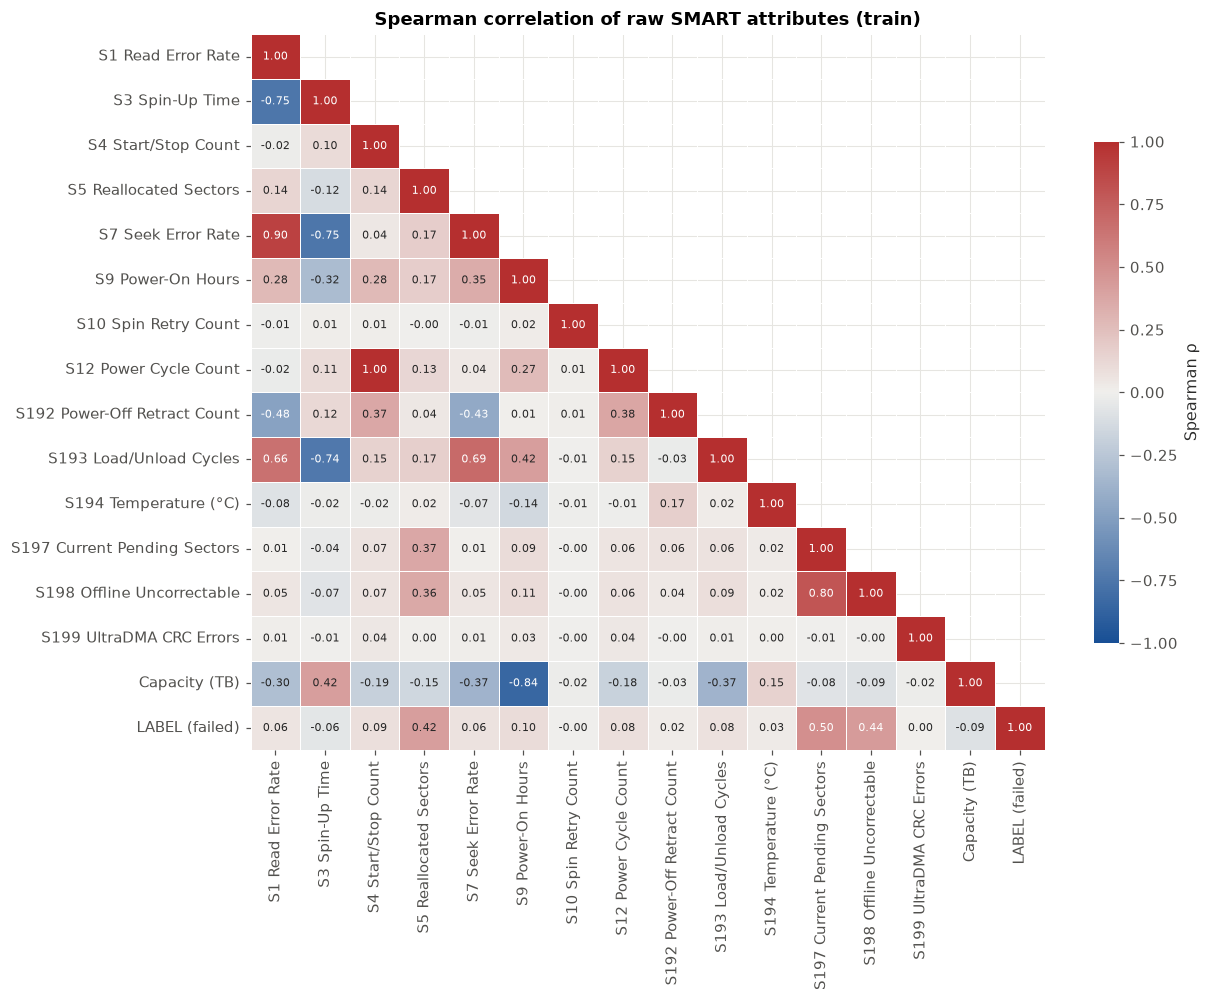

Most redundant pairs (|ρ| ≥ 0.6):


feature A,feature B,ρ
S4 Start/Stop Count,S12 Power Cycle Count,+0.997
S1 Read Error Rate,S7 Seek Error Rate,+0.901
S9 Power-On Hours,Capacity (TB),-0.845
S197 Current Pending Sectors,S198 Offline Uncorrectable,+0.803
S3 Spin-Up Time,S7 Seek Error Rate,-0.755
S1 Read Error Rate,S3 Spin-Up Time,-0.754
S3 Spin-Up Time,S193 Load/Unload Cycles,-0.736
S7 Seek Error Rate,S193 Load/Unload Cycles,+0.692
S1 Read Error Rate,S193 Load/Unload Cycles,+0.656


In [53]:
cols = [f"smart_{i}_raw_last" for i in SMART_IDS] + ["capacity_tb", "label"]
corr = train[cols].corr(method="spearman")
corr.index = corr.columns = [sname(i) for i in SMART_IDS] + ["Capacity (TB)", "LABEL (failed)"]
mask = np.triu(np.ones_like(corr, bool), k=1)
fig, ax = plt.subplots(figsize=(11.5, 9.2))
sns.heatmap(corr, mask=mask, cmap=DIVERGING, vmin=-1, vmax=1, center=0, annot=True, fmt=".2f", annot_kws={"fontsize": 7.5},
            linewidths=0.6, linecolor="white", cbar_kws={"shrink": 0.7, "label": "Spearman ρ"}, ax=ax)
ax.set_title("Spearman correlation of raw SMART attributes (train)")
plt.tight_layout(); plt.show()

pairs = (corr.where(~np.tril(np.ones_like(corr, bool))).stack().rename("ρ").reset_index()
         .rename(columns={"level_0": "feature A", "level_1": "feature B"}))
pairs = pairs[~pairs["feature B"].str.startswith("LABEL")].reindex(pairs["ρ"].abs().sort_values(ascending=False).index)
print("Most redundant pairs (|ρ| ≥ 0.6):")
display(pairs[pairs["ρ"].abs() >= 0.6].head(12).style.format({"ρ": "{:+.3f}"}).hide(axis="index"))

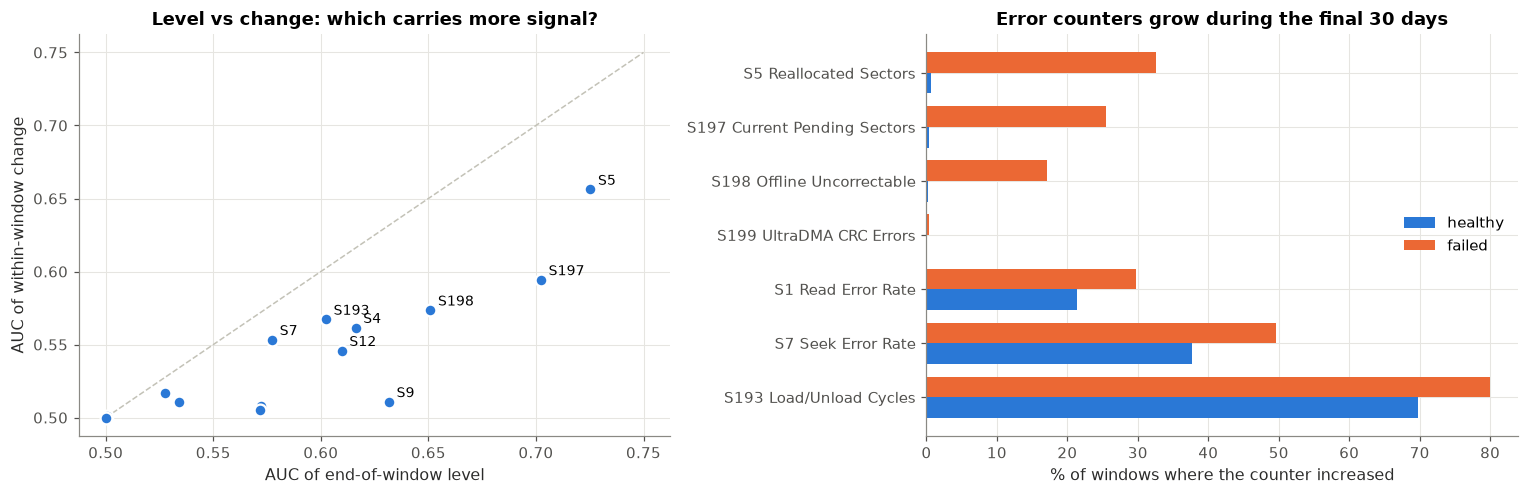

,AUC last (level),AUC delta (change),% failed with increase,% healthy with increase,lift (fail/healthy)
attribute,,,,,
S5 Reallocated Sectors,0.725,0.656,32.6%,0.6%,54.1×
S197 Current Pending Sectors,0.702,0.594,25.4%,0.3%,81.9×
S198 Offline Uncorrectable,0.651,0.574,17.1%,0.2%,97.1×
S9 Power-On Hours,0.632,0.511,99.9%,99.9%,1.0×
S4 Start/Stop Count,0.616,0.562,20.9%,8.8%,2.4×
S12 Power Cycle Count,0.610,0.546,17.8%,8.8%,2.0×
S193 Load/Unload Cycles,0.602,0.567,80.0%,69.8%,1.1×
S7 Seek Error Rate,0.577,0.553,49.6%,37.6%,1.3×
S3 Spin-Up Time,0.572,0.508,3.8%,1.2%,3.1×


In [54]:
# is degradation *during* the window informative?
y = train.label.values
rows = []
for i in SMART_IDS:
    L = train[f"smart_{i}_raw_last"].values.astype(float)
    D = train[f"smart_{i}_raw_delta"].values.astype(float)
    inc_f = (train.loc[train.label == 1, f"smart_{i}_raw_delta"] > 0).mean()
    inc_h = (train.loc[train.label == 0, f"smart_{i}_raw_delta"] > 0).mean()
    rows.append({"attribute": sname(i), "AUC last (level)": oriented_auc(y, L), "AUC delta (change)": oriented_auc(y, D),
                 "% failed with increase": inc_f, "% healthy with increase": inc_h, "lift (fail/healthy)": inc_f / max(inc_h, 1e-6)})
lvd = pd.DataFrame(rows).set_index("attribute").sort_values("AUC last (level)", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
ax = axes[0]
ax.scatter(lvd["AUC last (level)"], lvd["AUC delta (change)"], s=60, color=SERIES[0], edgecolors="white", linewidths=1.5, zorder=3)
for lab, r in lvd.iterrows():
    if r["AUC last (level)"] > 0.58 or r["AUC delta (change)"] > 0.54:
        ax.annotate(lab.split(" ", 1)[0], (r["AUC last (level)"], r["AUC delta (change)"]), xytext=(5, 3), textcoords="offset points", fontsize=9)
ax.plot([0.5, 0.75], [0.5, 0.75], ls="--", color="#c3c2b7", lw=1)
ax.set_xlabel("AUC of end-of-window level"); ax.set_ylabel("AUC of within-window change"); ax.set_title("Level vs change: which carries more signal?")

sub = lvd.loc[[sname(i) for i in [5, 197, 198, 199, 1, 7, 193]]]
yy = np.arange(len(sub)); h = 0.38
axes[1].barh(yy + h/2, sub["% healthy with increase"] * 100, h, color=HEALTHY, label="healthy")
axes[1].barh(yy - h/2, sub["% failed with increase"] * 100, h, color=FAILED, label="failed")
axes[1].set_yticks(yy, sub.index); axes[1].invert_yaxis(); axes[1].set_xlabel("% of windows where the counter increased")
axes[1].set_title("Error counters grow during the final 30 days"); axes[1].legend(loc="center right")
plt.tight_layout(); plt.show()
display(lvd.style.format({"AUC last (level)": "{:.3f}", "AUC delta (change)": "{:.3f}", "% failed with increase": "{:.1%}",
                          "% healthy with increase": "{:.1%}", "lift (fail/healthy)": "{:.1f}×"}))

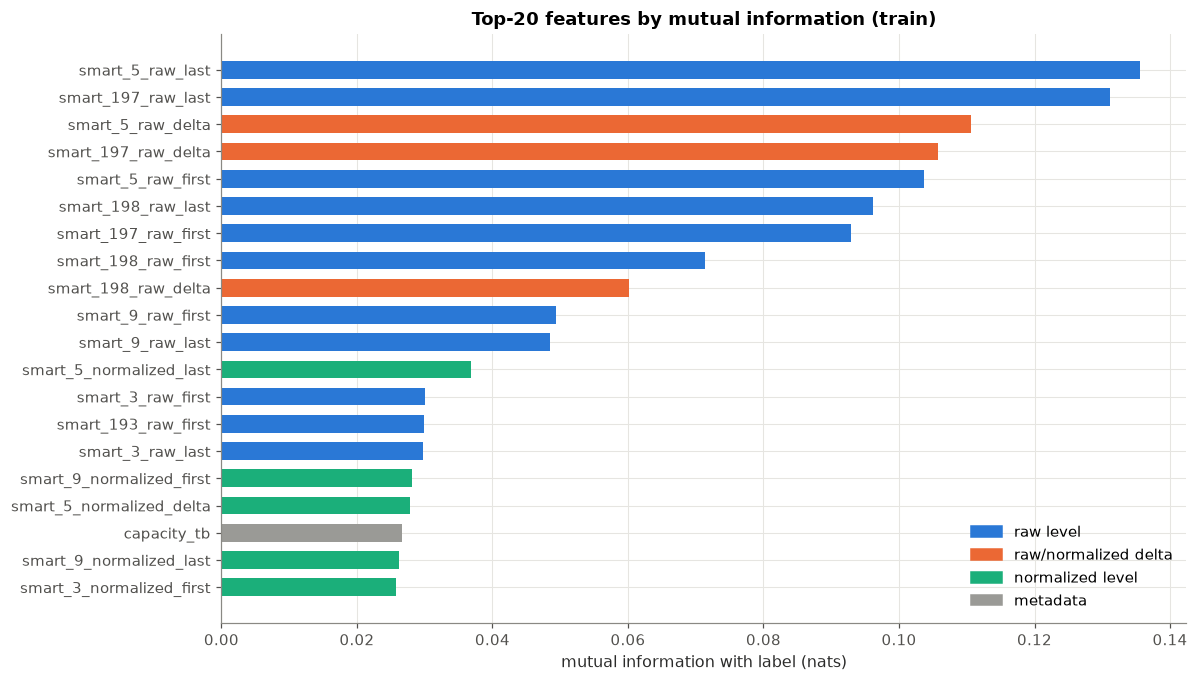

,sum,mean,max
metadata,0.0460,0.0230,0.0266
normalized,0.4715,0.0112,0.0369
raw,1.3510,0.0322,0.1356


In [55]:
# Mutual information ranking over every SMART feature + age + capacity
smart_cols = [c for c in train.columns if c.startswith("smart_")]
Xmi = train[smart_cols + ["capacity_tb", "drive_days_to_date"]].copy()
Xmi = Xmi.fillna(Xmi.median())
samp_idx = train.groupby("label", group_keys=False).apply(lambda g: g.sample(min(len(g), 25000), random_state=1)).index
mi = mutual_info_classif(Xmi.loc[samp_idx], train.loc[samp_idx, "label"], random_state=0, n_neighbors=5)
mi = pd.Series(mi, index=Xmi.columns).sort_values(ascending=False)

top = mi.head(20)[::-1]
def fam_col(c):
    if "_normalized_" in c: return SERIES[2]
    if c.endswith("_delta"): return SERIES[1]
    if "_raw_" in c: return SERIES[0]
    return "#9a9a96"
fig, ax = plt.subplots(figsize=(11, 6.3))
ax.barh(top.index, top.values, color=[fam_col(c) for c in top.index], height=0.65)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in [SERIES[0], SERIES[1], SERIES[2], "#9a9a96"]]
ax.legend(handles, ["raw level", "raw/normalized delta", "normalized level", "metadata"], loc="lower right")
ax.set_xlabel("mutual information with label (nats)"); ax.set_title("Top-20 features by mutual information (train)")
plt.tight_layout(); plt.show()

fam_mi = mi.groupby(lambda c: "normalized" if "_normalized_" in c else "raw" if "_raw_" in c else "metadata").agg(["sum", "mean", "max"])
display(fam_mi.style.format("{:.4f}"))

**Interpretation.**
We can see clear correlation between s4 and s12 so we can drop one. S1 and S7 also have a high correlation and their corelation with other attributs is similar thus onr of them could also be dropped. S197 and S198 are strongly related but their correaltion with other attributs id not identical, so both stay. Anothor noticable obervation is the taht the capacity. Dot  and bar chart show that in their final month, 33% of dying drives got new bad sectors, against 0.6% of healthy ones. Change during the month is a strong clue for failure. The mutual information section shows that the top 11 features are raw this confirms that the raw values carry more data about failure than teh normalized oones.

---
## 10. Conclusions: What the Data Tells Us

### Dataset
The data comes from Backblaze Drive Stats (public, automatically collected from production drive firmware, widely used in research). It has 94 columns; 14 SMART attributes × {raw, normalized} × {first, last, delta}, plus metadata. Every integrity check we ran passed: unique keys, temporal separation, label logic, an exact 20:1 sampling ratio, physically plausible values, and an AFR of 1.3% in line with Backblaze's published figures.

### Five Key Findings

1. Class imbalace: Train set has a 4.76% failure rate vs 0.106% in the test set. To counter this we need to use PR-AUC and recall in order to test the model.
2. Who fails: Afr varies accross model and accross vendors. Infant mortality and mortality with age is also obseverd, thus including these attribute while trainig is important. 
3. SMART signatures: S5/S197/S198 having non-zero values greatly increase the mortality rate. Due to this we can convert these too binary values, however for som attributes half of failures show no warning.
4. Raw vs Normalized: Vendor normalization compresses, saturates and is vendor-specific. In order to counter this we need to train our modle on raw attributes and drop the redundant and leaky normalized attributes.
5. Redundancy: Some attributes S4≈S12 (ρ = 0.997), S197~S198 (0.80), can be dropped as they are similar and we must keep features thet are indepandant.

### Risks

1. The train set is older than the test set and the model might not detect failure patterns for newer models.
2. Some vemdor specific attributes can create noise and distract the model.
3. There are a couple of Non-random missing values which are vendor specific thus we can not interpolate or remove them.

